# TSTR Evaluation


In [51]:
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

from core.data import load_dataset, split_dataset, BreathDataset
from models.vae import VAE, CVAE
from models.gan import CGAN

plt.rcParams.update({'legend.fontsize': 9,
                     'axes.titlesize': 10})

In [48]:
RESULT_DIR = 'results/tstr'
SEEDS = [7, 42, 123]
REGIONS = ['mouth', 'nose']
REGION_STYLE = {'mouth': '-', 'nose': '--'}
CLASSES = ['bradypnea', 'eupnea', 'tachypnea']
CLASS_COLORS = {'bradypnea': 'tab:blue', 'eupnea': 'tab:green', 'tachypnea': 'tab:purple'}
MODELS = ['trtr', 'cvae', 'vae', 'gan']
MODEL_COLOR = {'trtr': 'tab:blue', 'cvae': 'tab:green', 'vae': 'tab:orange', 'gan': 'tab:red'}
CHANNEL_NAMES = ['Humidity in %', 'Temperature in °C']
device = torch.device('cuda' if torch.cuda.is_available() else
                      'mps' if torch.backends.mps.is_available() else 'cpu')


### Summary

In [ ]:
# load json files
records = []
for path in glob.glob(f'{RESULT_DIR}/*.json'):
    with open(path) as f:
        records.append(json.load(f))

# load summary
df = pd.read_csv(f'{RESULT_DIR}/summary.csv')
df['model'] = pd.Categorical(df['model'], categories=MODELS, ordered=True)
df = df.sort_values(['region', 'model', 'seed']).reset_index(drop=True)

print(df.to_string(index=False))

In [ ]:
# average summary
metrics_cols = ['accuracy', 'f1_weighted', 'roc_auc_ovr', 'log_loss', 'f1_bradypnea', 'f1_eupnea', 'f1_tachypnea', 'feature_overlap']
agg = df.groupby(['model', 'region'], observed=True)[metrics_cols].agg(['mean', 'std']).round(3)
rows = []
for (model, region), g in df.groupby(['model', 'region'], observed=True):
    row = {'model': model, 'region': region}
    for m in metrics_cols:
        mu = g[m].mean()
        sd = g[m].std()
        if pd.isna(sd) or len(g) < 2:
            row[m] = f'{mu:.3f}'
        else:
            row[m] = f'{mu:.3f} ± {sd:.3f}'
    rows.append(row)

summary = pd.DataFrame(rows)
summary['model'] = pd.Categorical(summary['model'], categories=MODELS, ordered=True)
summary = summary.sort_values(['region', 'model']).reset_index(drop=True)
print(summary.to_string(index=False))

In [ ]:
# results relative to trtr baseline
metrics_main = ['accuracy', 'f1_weighted', 'roc_auc_ovr', 'log_loss']
metric_labels = ['Accuracy', 'F1 (weighted)', 'ROC-AUC (OvR)', 'Log Loss']

rows = []
for region in REGIONS:
    trtr_vals = df[(df.model == 'trtr') & (df.region == region)]
    trtr_means = {m: trtr_vals[m].mean() for m in metrics_main}
    for model in MODELS:
        model_rows = df[(df.model == model) & (df.region == region)]
        entry = {'model': model, 'region': region}
        for m in metrics_main:
            t = trtr_means[m]
            vals = model_rows[m].values
            if m == 'log_loss':
                ratios = t / vals if np.all(vals > 0) else np.full(len(vals), np.nan)
            else:
                ratios = vals / t if t > 0 else np.full(len(vals), np.nan)
            entry[f'{m}_mean'] = np.nanmean(ratios)
            entry[f'{m}_std'] = np.nanstd(ratios, ddof=1)
        rows.append(entry)

util_df = pd.DataFrame(rows)
fig, axes = plt.subplots(1, len(metrics_main), figsize=(14, 4), sharey=True)
x = np.arange(2)
width = 0.15
for ax, m, label in zip(axes, metrics_main, metric_labels):
    for i, model in enumerate(MODELS):
        if model == 'trtr':
            continue
        means = [util_df[(util_df.model == model) & (util_df.region == r)][f'{m}_mean'].values[0] for r in REGIONS]
        stds  = [util_df[(util_df.model == model) & (util_df.region == r)][f'{m}_std'].values[0]  for r in REGIONS]
        bars = ax.bar(x + i * width, means, width, label=model.upper(), color=MODEL_COLOR[model], alpha=0.85)
        ax.errorbar(x + i * width, means, yerr=stds, fmt='none', color='black', capsize=3, linewidth=1)
        # for bar, v in zip(bars, means):
        #     ax.text(bar.get_x() + bar.get_width()/2 + 0.075, bar.get_height() + 0.01, f'{v:.2f}', ha='center', va='bottom', fontsize=8)
    ax.axhline(1.0, linewidth=1, label='TRTR baseline')
    ax.set_title(label)
    ax.set_xticks(x + width)
    ax.set_xticklabels(REGIONS)
    ax.set_ylim(0, 1.35)
    ax.set_ylabel('Utility score' if label == metric_labels[0] else '')
    ax.legend(loc='upper right') if m == metrics_main[3] else None
    ax.grid()

plt.tight_layout()
plt.show()

In [ ]:
# absolute results
fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
axes = axes.flatten()
metrics_abs = ['accuracy', 'f1_weighted', 'roc_auc_ovr', 'log_loss']
metric_labels_abs = ['Accuracy', 'F1 (weighted)', 'ROC-AUC (OvR)', 'Log Loss ↓']
invert = [False, False, False, True]
x = np.arange(len(MODELS))
width = 0.35
hatch = {'mouth': '', 'nose': '//'}
for ax, m, label, inv in zip(axes, metrics_abs, metric_labels_abs, invert):
    for j, region in enumerate(REGIONS):
        means = [df[(df.model == mo) & (df.region == region)][m].mean() for mo in MODELS]
        stds  = [df[(df.model == mo) & (df.region == region)][m].std()  for mo in MODELS]
        bars = ax.bar(x + j * width, means, width, label=region, color=[MODEL_COLOR[mo] for mo in MODELS], hatch=hatch[region], alpha=0.85, edgecolor='white')
        ax.errorbar(x + j * width, means, yerr=stds, fmt='none', color='black', capsize=3, linewidth=1)
        # for bar, v in zip(bars, means):
        #     ax.text(bar.get_x() + bar.get_width() / 2 + 0.2, bar.get_height() + 0.005, f'{v:.2f}', ha='center', va='bottom', fontsize=7.5)
    ax.set_title(label)
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels([mo.upper() for mo in MODELS])
    legend_patches = [mpatches.Patch(facecolor='silver', edgecolor='black', hatch=hatch[r], label=r) for r in REGIONS]
    ax.legend(handles=legend_patches, loc='upper left') if m == metrics_abs[3] else None

model_patches = [mpatches.Patch(facecolor=MODEL_COLOR[m], label=m.upper()) for m in MODELS]
plt.tight_layout()
plt.show()

In [ ]:
# class-wise F1 scores
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, region in zip(axes, REGIONS):
    matrix_mean, matrix_std, row_labels = [], [], []
    for model in MODELS:
        rows_data = df[(df.model == model) & (df.region == region)]
        means = [rows_data[f'f1_{c}'].mean() for c in CLASSES]
        stds  = [rows_data[f'f1_{c}'].std()  for c in CLASSES]
        matrix_mean.append(means)
        matrix_std.append(stds)
        row_labels.append(model.upper())

    mat     = np.array(matrix_mean)
    mat_std = np.array(matrix_std)
    im = ax.imshow(mat, vmin=0, vmax=1, cmap='viridis', aspect='equal')

    ax.set_xticks(range(len(CLASSES)))
    ax.set_xticklabels(CLASSES)
    ax.set_yticks(range(len(MODELS)))
    ax.set_yticklabels(row_labels)
    ax.set_title(f'Region: {region}')

    for i in range(len(MODELS)):
        for j in range(len(CLASSES)):
            v, s = mat[i, j], mat_std[i, j]
            text = f'{v:.2f}\n±{s:.2f}' if not np.isnan(s) else f'{v:.2f}'
            ax.text(j, i, text, ha='center', va='center', fontsize=7.5,
                    color='white' if v < 0.5 else 'black')

plt.colorbar(im, ax=axes[-1], label='F1 score (mean)')
plt.tight_layout()
plt.show()

In [ ]:
# feature overlap
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(2)
width = 0.3
for i, model in enumerate(MODELS):
    if model == 'trtr':
        continue
    means = [df[(df.model == model) & (df.region == r)]['feature_overlap'].mean() for r in REGIONS]
    stds  = [df[(df.model == model) & (df.region == r)]['feature_overlap'].std()  for r in REGIONS]
    bars = ax.bar(x + i * width, means, width, label=model.upper(), color=MODEL_COLOR[model], alpha=0.85)
    ax.errorbar(x + i * width, means, yerr=stds, fmt='none', color='black', capsize=3, linewidth=1)
    # for bar, v in zip(bars, means):
    #     ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f'{v:.1%}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x + width / 2)
ax.set_xticklabels(REGIONS)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Overlap')
ax.set_title('Top-10 SHAP Feature Overlap: Synthetic vs Real')
ax.legend()
plt.tight_layout()
plt.show()

### VAE

In [56]:
models = {seed: {} for seed in SEEDS}
datasets = {seed: {} for seed in SEEDS}
splits = {seed: {} for seed in SEEDS}

for seed in SEEDS:
    for region in REGIONS:
        # load dataset
        df = load_dataset()
        df = df[df["region"] == region].reset_index(drop=True)
        df_train, df_val, df_test = split_dataset(df, random_state=seed)

        # datasets
        train_ds = BreathDataset(df_train)
        val_ds = BreathDataset(df_val,  stats=train_ds.stats)
        test_ds = BreathDataset(df_test, stats=train_ds.stats)
        datasets[seed][region] = {"train": train_ds, "val": val_ds, "test": test_ds}
        splits[seed][region] = {"train": df_train, "val": df_val, "test": df_test}

        # model
        ckpt_path = f"models/checkpoints/vae_{region}_s{seed}.pt"
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
        model = VAE(latent_dim=ckpt['latent_dim']).to(device)
        model.load_state_dict(ckpt['model_state'])
        model.eval()
        models[seed][region] = model

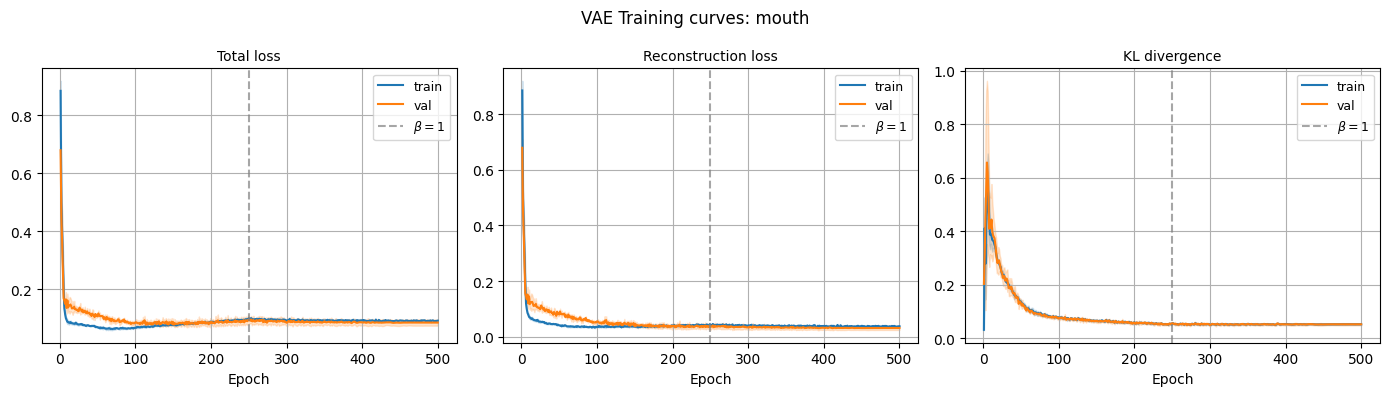

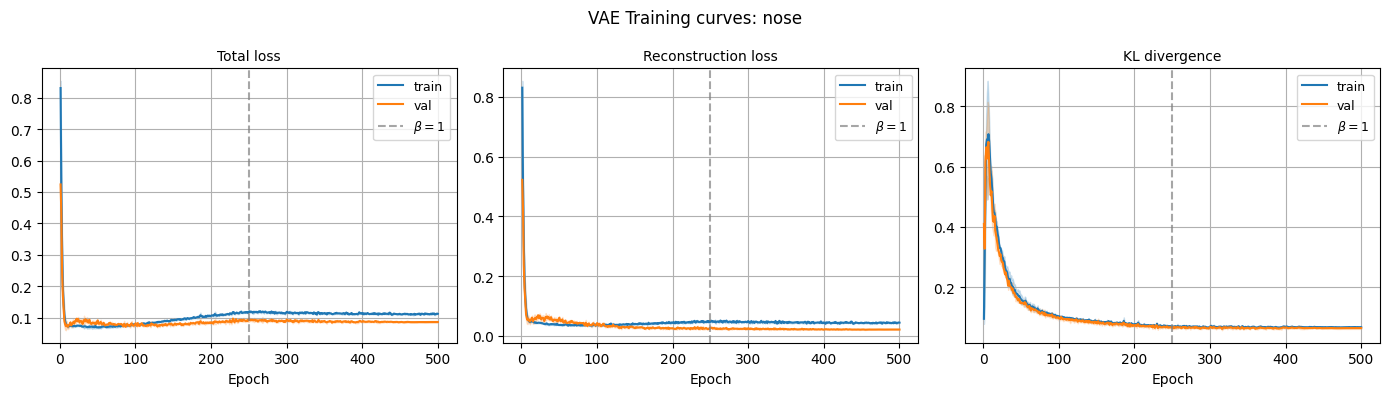

In [57]:
pairs = [('train_loss',  'val_loss',  'Total loss'),
         ('train_recon', 'val_recon', 'Reconstruction loss'),
         ('train_kl',    'val_kl',    'KL divergence')]

for region in REGIONS:
    hists = [pd.read_csv(f'results/vae/train_{region}_s{seed}.csv') for seed in SEEDS]
    epochs = hists[0]['epoch'].values
    beta1_med = int(np.median([h.loc[h['beta'] >= 1.0, 'epoch'].min() for h in hists]))

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(f'VAE Training curves: {region}')

    for ax, (tr_col, vl_col, title) in zip(axes, pairs):
        for col, label, color in [(tr_col, 'train', 'tab:blue'), (vl_col, 'val', 'tab:orange')]:
            vals = np.stack([h[col].values for h in hists])  # (n_seeds, n_epochs)
            mean = vals.mean(axis=0)
            std  = vals.std(axis=0)
            ax.plot(epochs, mean, label=label, color=color)
            ax.fill_between(epochs, mean - std, mean + std, alpha=0.2, color=color)
        ax.axvline(beta1_med, color='gray', linestyle='--', alpha=0.7, label=r'$\beta=1$')
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid()

    plt.tight_layout()
    plt.show()

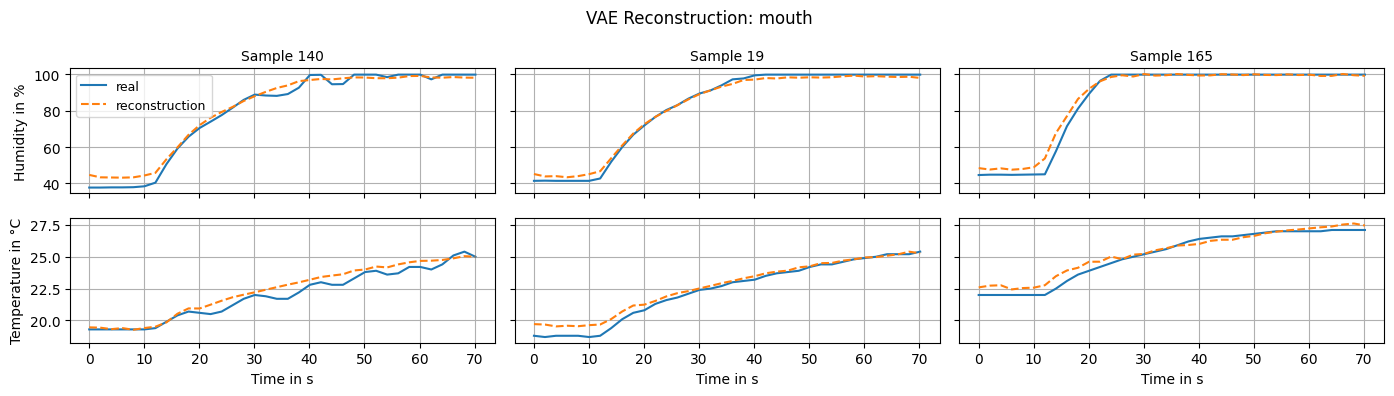

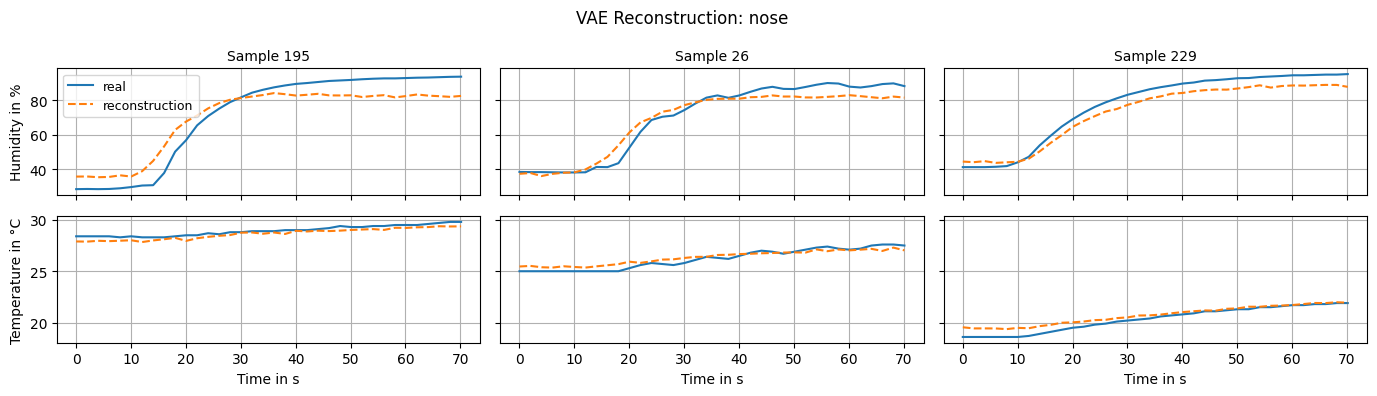

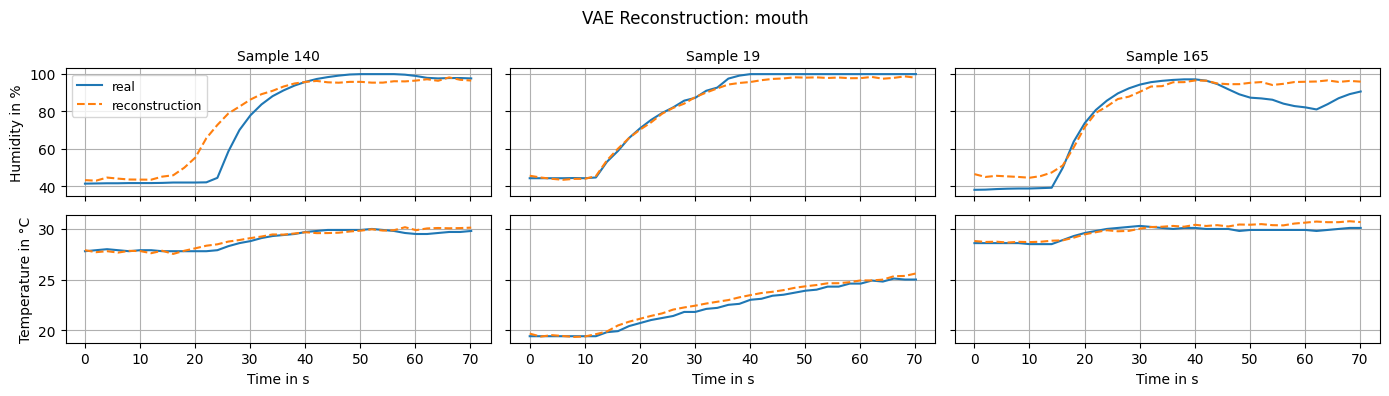

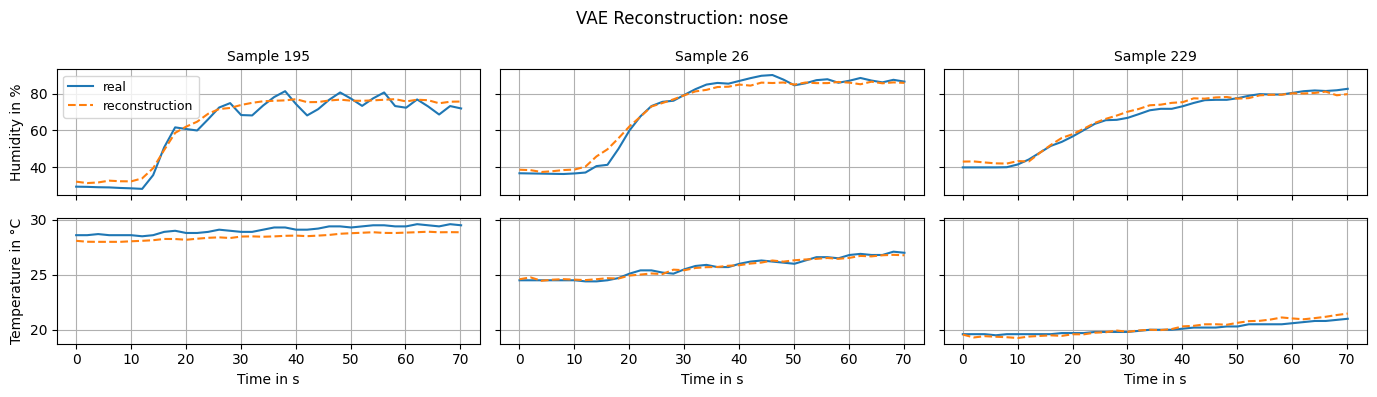

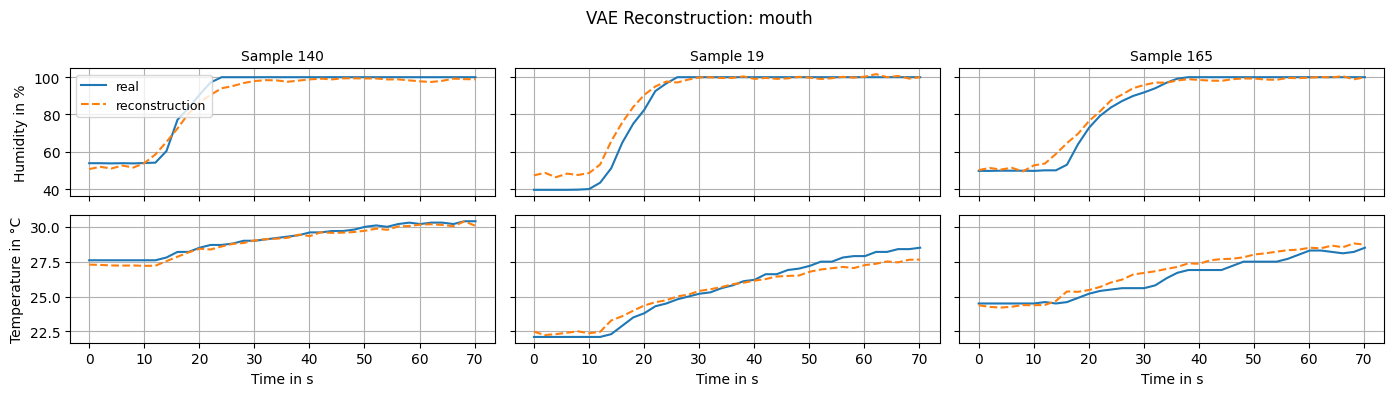

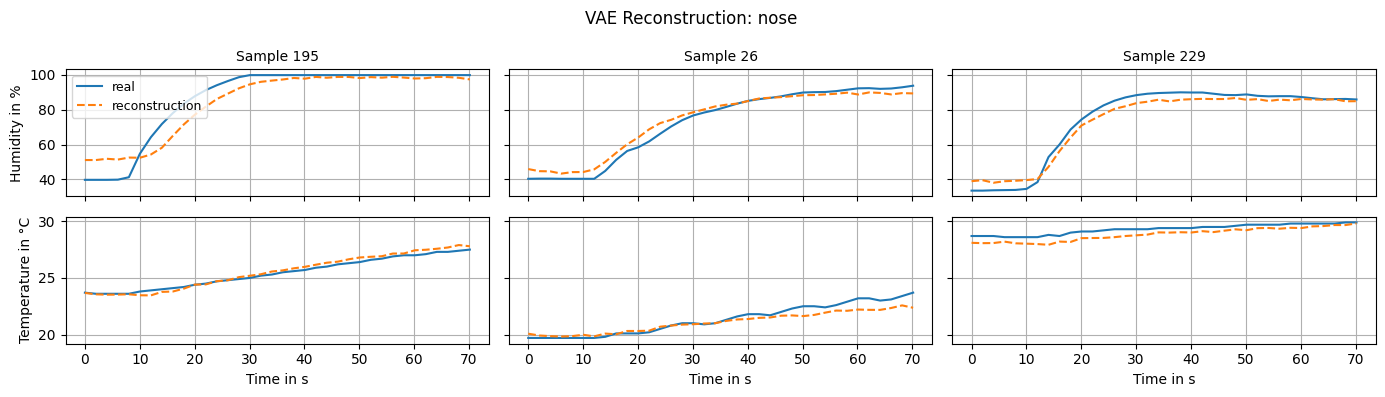

In [59]:
for seed in SEEDS:
    for region in REGIONS:
        train_ds = datasets[seed][region]['train']
        model = models[seed][region]
        model.eval()

        # denormalization
        mean = train_ds.stats['mean'][:, None]
        std  = train_ds.stats['std'][:, None]
        def denorm(x):
            return x * std + mean

        fig, axes = plt.subplots(2, 3, figsize=(14, 4), sharex=True, sharey='row')
        fig.suptitle(f'VAE Reconstruction: {region}')

        # sample 3 signals from train_ds
        sample_indices = np.random.default_rng(42).choice(len(train_ds), size=3, replace=False)
        for col, idx in enumerate(sample_indices):
            signal, time, label = train_ds[idx]
            signal_batch = signal.unsqueeze(0).to(device)
            with torch.no_grad():
                x_hat, _, _ = model(signal_batch)
            x_hat      = denorm(x_hat.squeeze(0).cpu().numpy())
            signal_np  = denorm(signal.numpy())
            time_np    = time.numpy()

            for row in range(2):
                ax = axes[row, col]
                ax.plot(time_np, signal_np[row], label='real', color='tab:blue')
                ax.plot(time_np, x_hat[row], label='reconstruction', color='tab:orange', linestyle='--')
                ax.grid()
                axes[row, 0].set_ylabel(CHANNEL_NAMES[row])
                axes[0, col].set_title(f'Sample {idx}')
                axes[0, 0].legend(loc='upper left')
                axes[-1, col].set_xlabel('Time in s')
        plt.tight_layout()
        plt.show()

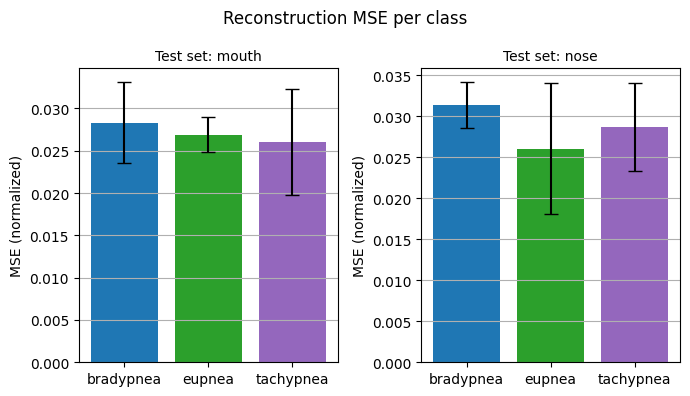

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(7, 4))
plt.suptitle('Reconstruction MSE per class')

for region_idx, region in enumerate(REGIONS):
    # collect per-seed mean MSE per class, then aggregate across seeds
    seed_means = {i: [] for i in range(len(CLASSES))}
    for seed in SEEDS:
        test_ds = datasets[seed][region]['test']
        model = models[seed][region]
        model.eval()
        mse_per_class = {i: [] for i in range(len(CLASSES))}
        with torch.no_grad():
            for i in range(len(test_ds)):
                signal, _, label = test_ds[i]
                x_hat, _, _ = model(signal.unsqueeze(0).to(device))
                mse = (x_hat.squeeze(0) - signal.to(device)).pow(2).mean().item()
                mse_per_class[label].append(mse)
        for cls_idx in range(len(CLASSES)):
            seed_means[cls_idx].append(np.mean(mse_per_class[cls_idx]))

    means = [np.mean(seed_means[i]) for i in range(len(CLASSES))]
    stds  = [np.std(seed_means[i])  for i in range(len(CLASSES))]

    axes[region_idx].bar(CLASSES, means, yerr=stds, capsize=5, color=list(CLASS_COLORS.values()))
    axes[region_idx].set_ylabel('MSE (normalized)')
    axes[region_idx].set_title(f'Test set: {region}')
    axes[region_idx].grid(axis='y')

plt.tight_layout()
plt.show()

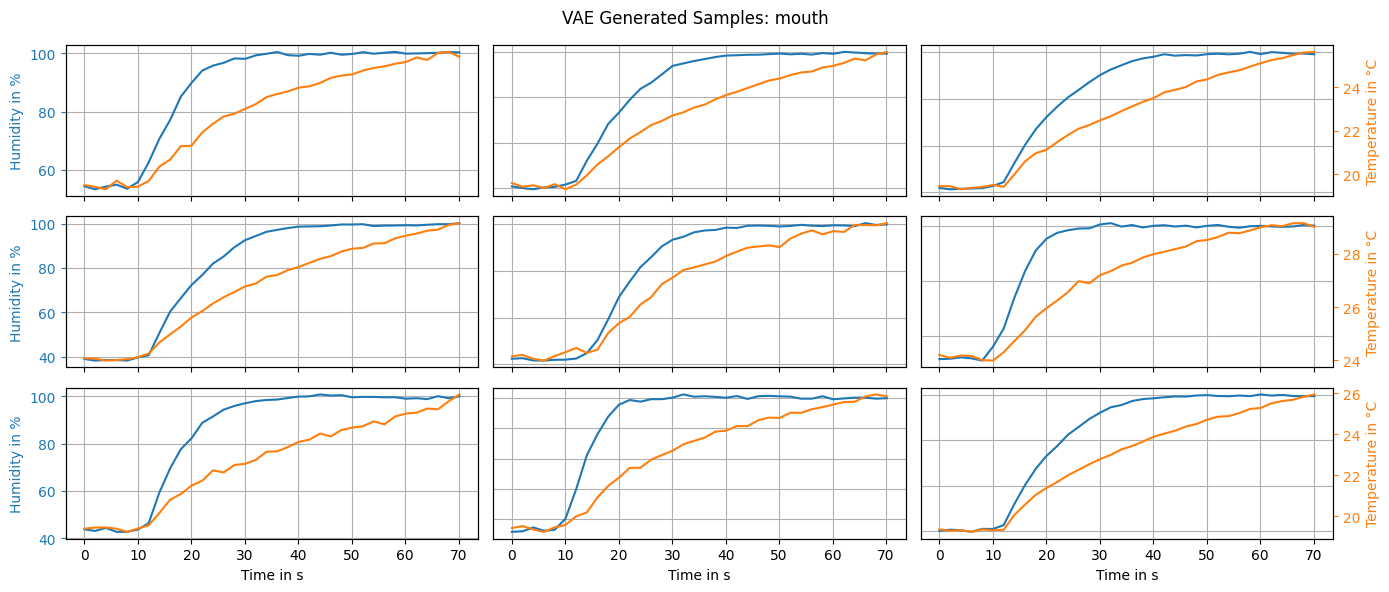

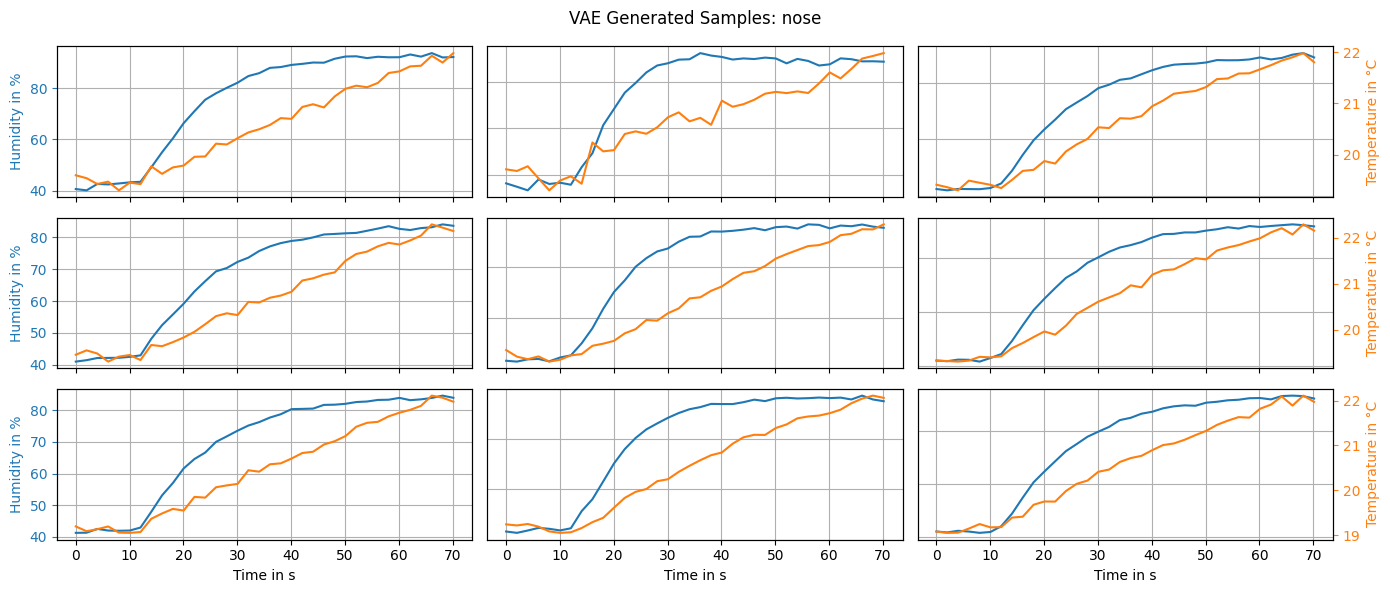

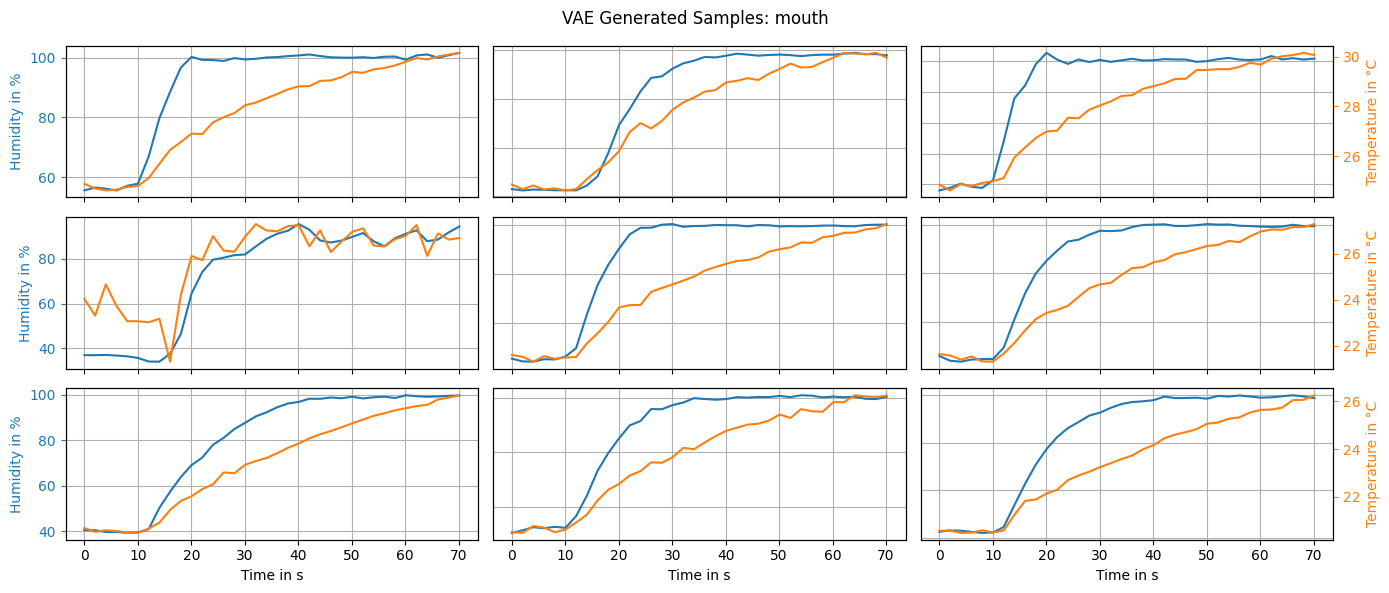

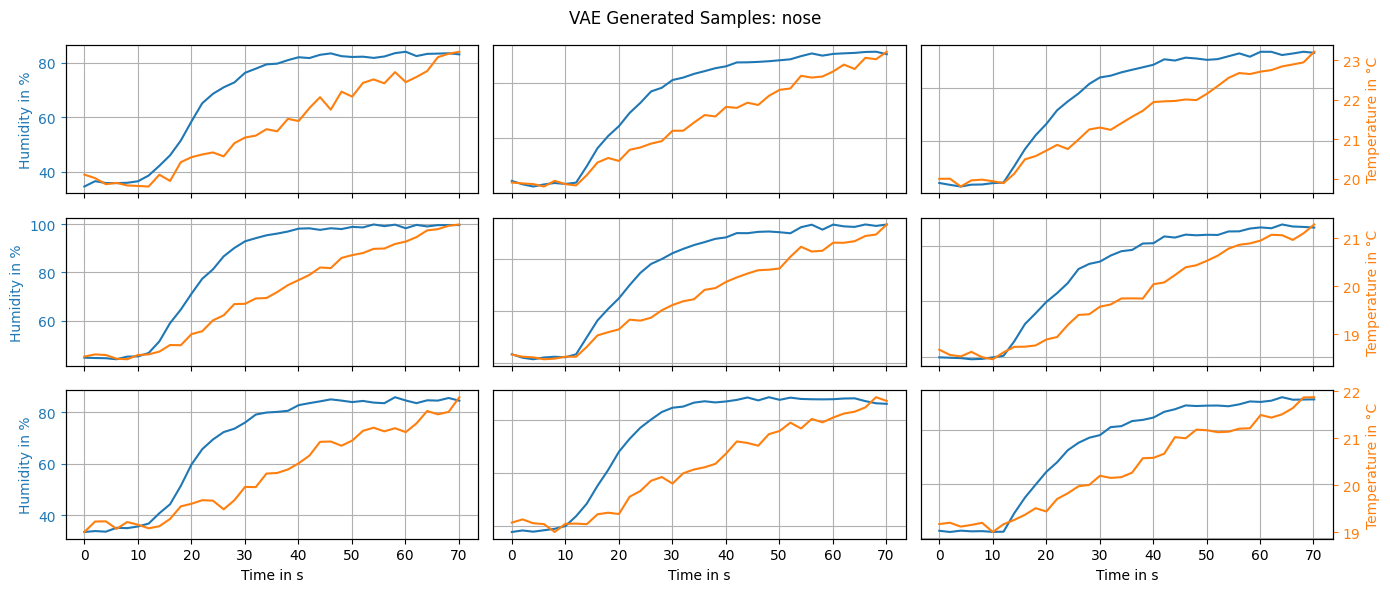

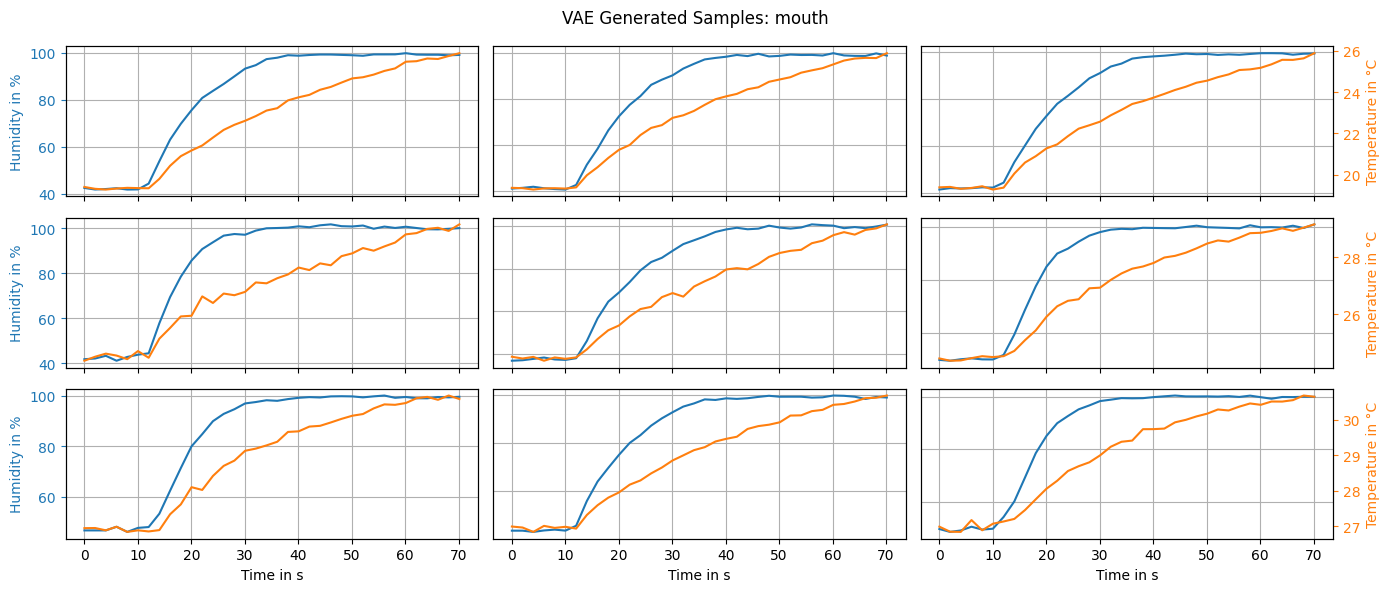

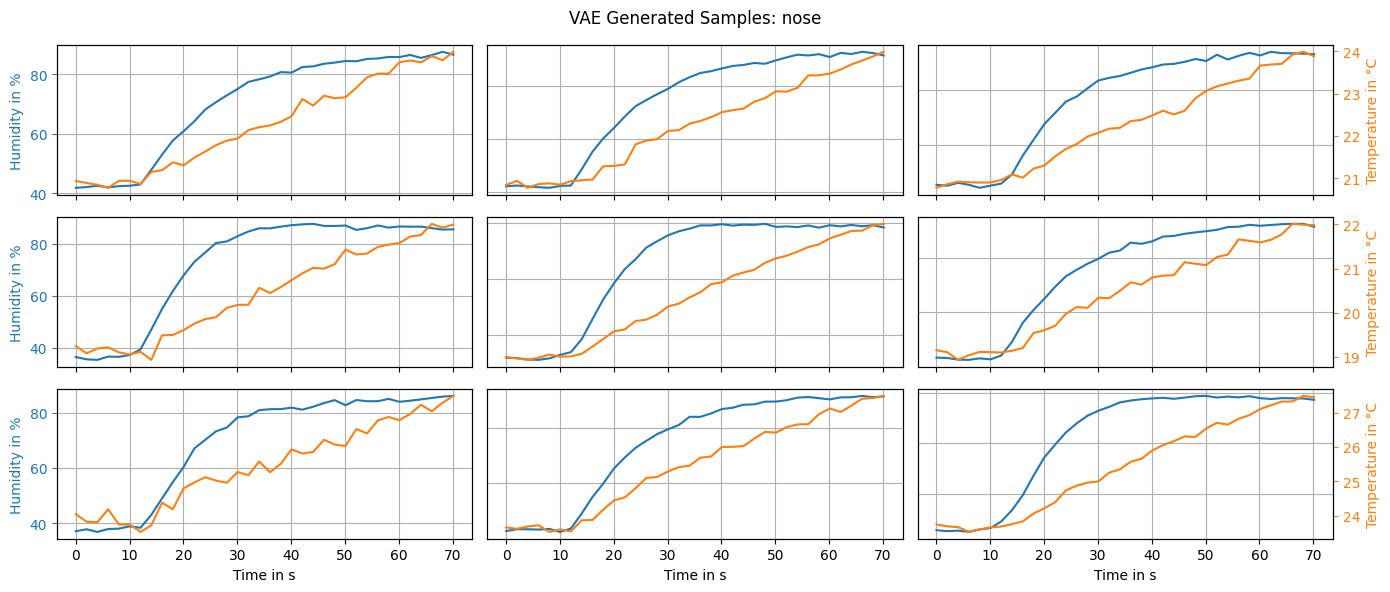

In [65]:
for seed in SEEDS:
    for region in REGIONS:
        train_ds = datasets[seed][region]['train']
        model = models[seed][region]
        model.eval()
        
        # denormalization
        mean = train_ds.stats['mean'][:, None]
        std  = train_ds.stats['std'][:, None]
        def denorm(x):
            return x * std + mean
        
        # plot
        samples  = denorm(model.sample(9, device).cpu().numpy())
        time_np  = train_ds[0][1].numpy()

        fig, axes = plt.subplots(3, 3, figsize=(14, 6), sharex=True, sharey=False)
        fig.suptitle(f'VAE Generated Samples: {region}')
        for i, ax in enumerate(axes.flatten()):
            row = i // 3
            col = i % 3
            l1, = ax.plot(time_np, samples[i, 0], color='tab:blue', label='Humidity in %')
            ax.grid()
            ax_r = ax.twinx()
            l2, = ax_r.plot(time_np, samples[i, 1], color='tab:orange', label='Temperature in °C')
            if col == 0:
                ax.set_ylabel('Humidity in %', color='tab:blue')
                ax.tick_params(axis='y', colors='tab:blue')
            else:
                ax.set_yticklabels([])
                ax.tick_params(axis='y', length=0)
            if col == 2:
                ax_r.set_ylabel('Temperature in °C', color='tab:orange')
                ax_r.tick_params(axis='y', colors='tab:orange')
            else:
                ax_r.set_yticklabels([])
                ax_r.tick_params(axis='y', length=0)
            if row == 2:
                ax.set_xlabel('Time in s')
        plt.tight_layout()
        plt.show()


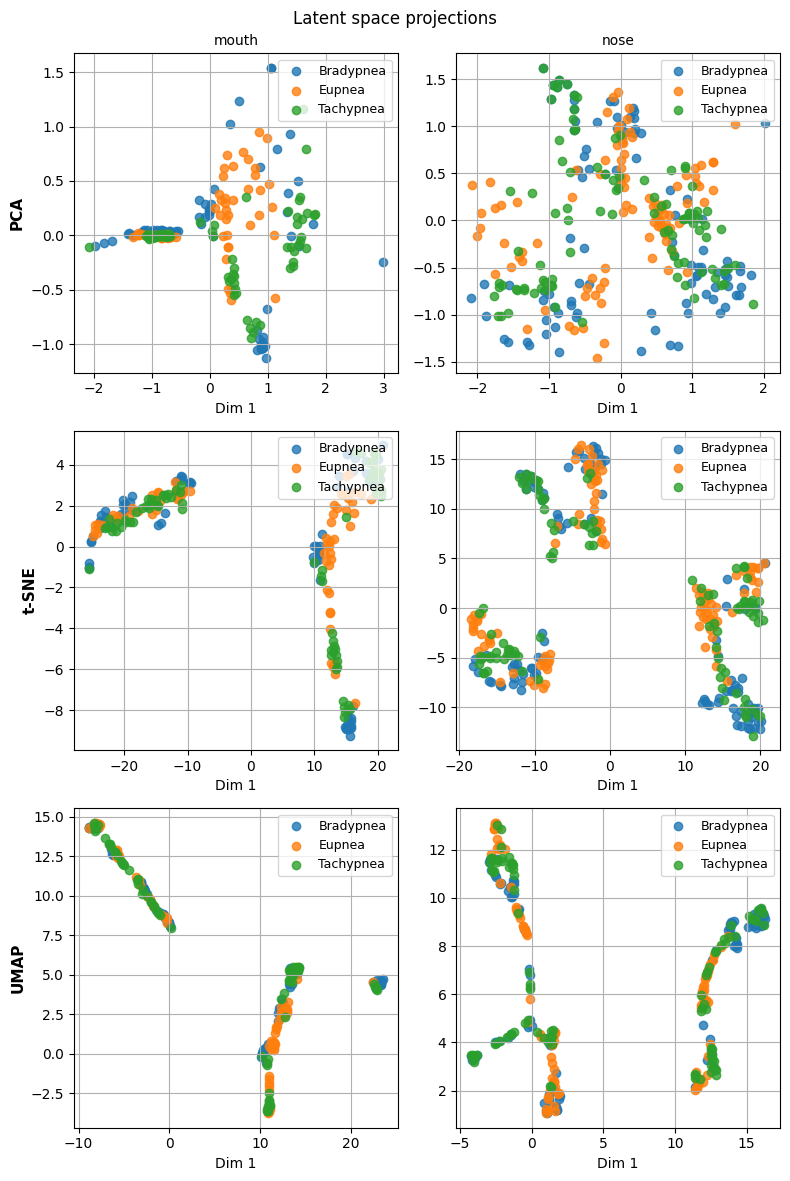

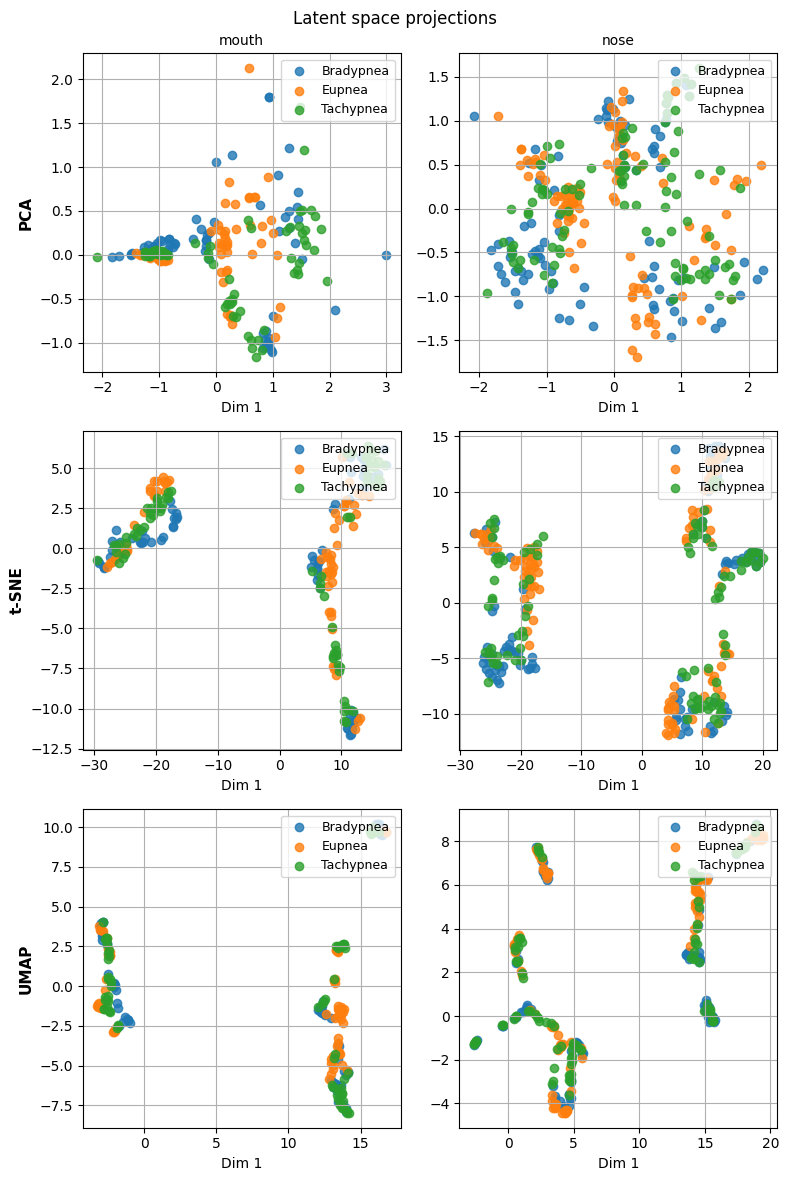

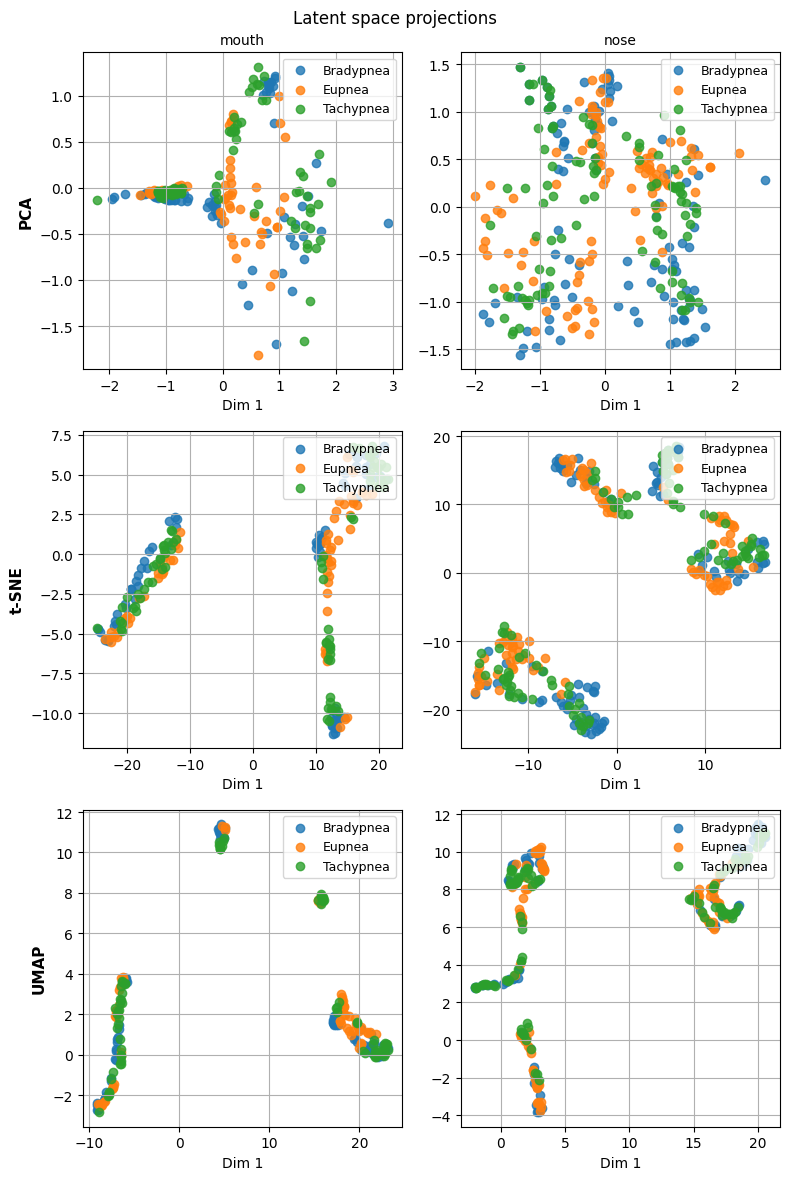

In [66]:
for seed in SEEDS:
    fig, axes = plt.subplots(3, 2, figsize=(8, 12))
    plt.suptitle('Latent space projections')

    methods = [
        ('PCA',   lambda z: PCA(n_components=2).fit_transform(z)),
        ('t-SNE', lambda z: TSNE(n_components=2, random_state=42).fit_transform(z)),
        ('UMAP',  lambda z: umap.UMAP(n_components=2, random_state=42, n_jobs=1).fit_transform(z)),
    ]

    for col, region in enumerate(REGIONS):
        train_ds = datasets[seed][region]['train']
        model = models[seed][region]
        model.eval()

        mus, labels = [], []
        with torch.no_grad():
            for i in range(len(train_ds)):
                signal, _, label = train_ds[i]
                mu, _ = model.encoder(signal.unsqueeze(0).to(device))
                mus.append(mu.squeeze(0).cpu().numpy())
                labels.append(label)
        mus    = np.stack(mus)
        labels = np.array(labels)

        for row, (method_name, project) in enumerate(methods):
            z2d = project(mus)
            ax  = axes[row, col]
            for i, cls in enumerate(CLASSES):
                mask = labels == i
                ax.scatter(z2d[mask, 0], z2d[mask, 1], label=cls.capitalize(), alpha=0.8)
            if row == 0:
                ax.set_title(region)
            if col == 0:
                ax.set_ylabel(method_name, fontsize=11, fontweight='bold')
            ax.set_xlabel('Dim 1')
            ax.legend(loc='upper right')
            ax.grid()

    plt.tight_layout()
    plt.show()

### CVAE

In [ ]:
REGIONS = ['mouth', 'nose']
CHANNEL_NAMES = ['Humidity in %', 'Temperature in °C']
CLASS_COLORS = {'bradypnea': 'tab:blue', 'eupnea': 'tab:green', 'tachypnea': 'tab:purple'}
device = torch.device('cuda' if torch.cuda.is_available() else
                      'mps' if torch.backends.mps.is_available() else 'cpu')
models = {} 
datasets = {}
splits = {}

for region in REGIONS:
    # load dataset
    df = load_dataset()
    df = df[df["region"] == region].reset_index(drop=True)
    df_train, df_val, df_test = split_dataset(df, random_state=42)

    # datasets
    train_ds = BreathDataset(df_train)
    val_ds = BreathDataset(df_val,  stats=train_ds.stats)
    test_ds = BreathDataset(df_test, stats=train_ds.stats)
    datasets[region] = {"train": train_ds, "val": val_ds, "test": test_ds}
    splits[region] = {"train": df_train, "val": df_val, "test": df_test}

    # model
    ckpt_path = f"models/checkpoints/cvae_{region}.pt"
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model = CVAE(latent_dim=ckpt['latent_dim'], embed_dim=ckpt['embed_dim']).to(device)
    model.load_state_dict(ckpt['model_state'])
    model.eval()

    models[region] = model

In [ ]:
for region in REGIONS:
    path = f'results/cvae/train_{region}.csv'
    hist = pd.read_csv(path)
    beta1_epoch = hist.loc[hist['beta'] >= 1.0, 'epoch'].min()

    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
    fig.suptitle(f'Training curves: {region}')
    pairs = [('train_loss', 'val_loss', 'Total loss'),
            ('train_recon', 'val_recon','Reconstruction loss'),
            ('train_kl', 'val_kl', 'KL divergence')]
    for ax, (tr_col, vl_col, title) in zip(axes, pairs):
        ax.plot(hist['epoch'], hist[tr_col], label='train')
        ax.plot(hist['epoch'], hist[vl_col], label='val')
        ax.axvline(beta1_epoch, color='gray', linestyle='--', alpha=0.7, label=r'$\beta=1$')
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid()
    plt.tight_layout()
    plt.show()

In [ ]:
for region in REGIONS:
    train_ds = datasets[region]['train']
    model = models[region]
    model.eval()

    # denormalization
    mean = train_ds.stats['mean'][:, None]
    std  = train_ds.stats['std'][:, None]
    def denorm(x):
        return x * std + mean

    fig, axes = plt.subplots(2, 3, figsize=(14, 4), sharex=True, sharey='row')
    fig.suptitle(f'CVAE Reconstruction: {region}')

    # sample 3 signals from train_ds
    sample_indices = np.random.default_rng(42).choice(len(train_ds), size=3, replace=False)
    for col, idx in enumerate(sample_indices):
        signal, time, label = train_ds[idx]
        signal_batch = signal.unsqueeze(0).to(device)
        label_t = torch.tensor([label]).long().to(device)
        with torch.no_grad():
            x_hat, _, _ = model(signal_batch, label_t)
        x_hat      = denorm(x_hat.squeeze(0).cpu().numpy())
        signal_np  = denorm(signal.numpy())
        time_np    = time.numpy()

        for row in range(2):
            ax = axes[row, col]
            ax.plot(time_np, signal_np[row], label='real', color='tab:blue')
            ax.plot(time_np, x_hat[row], label='reconstruction', color='tab:orange', linestyle='--')
            ax.grid()
            axes[row, 0].set_ylabel(CHANNEL_NAMES[row])
            axes[0, col].set_title(f'Sample {idx} ({CLASSES[label]})')
            axes[0, 0].legend(loc='upper left')
            axes[-1, col].set_xlabel('Time in s')
    plt.tight_layout()
    plt.show()

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(7, 4))
plt.suptitle('Reconstruction MSE per class')
for region_idx, region in enumerate(REGIONS):
    test_ds = datasets[region]['test']
    model = models[region]
    model.eval()

    mse_per_class = {i: [] for i in range(len(CLASSES))}
    with torch.no_grad():
        for i in range(len(test_ds)):
            signal, _, label = test_ds[i]
            label_t = torch.tensor([label]).long().to(device)
            x_hat, _, _ = model(signal.unsqueeze(0).to(device), label_t)
            mse = (x_hat.squeeze(0) - signal.to(device)).pow(2).mean().item()
            mse_per_class[label].append(mse)
    means = [np.mean(mse_per_class[i]) for i in range(len(CLASSES))]
    stds  = [np.std(mse_per_class[i])  for i in range(len(CLASSES))]

    ax = fig.axes[region_idx]
    ax.bar(CLASSES, means, yerr=stds, capsize=5, color=list(CLASS_COLORS.values()))
    ax.set_ylabel('MSE (normalized)')
    ax.set_title(f'Test set: {region}')
    ax.grid(axis='y')
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(10, 12))
plt.suptitle('Latent space projections')

methods = [
    ('PCA',   lambda z: PCA(n_components=2).fit_transform(z)),
    ('t-SNE', lambda z: TSNE(n_components=2, random_state=42).fit_transform(z)),
    ('UMAP',  lambda z: umap.UMAP(n_components=4, random_state=42, n_jobs=1).fit_transform(z)),
]

for col, region in enumerate(REGIONS):
    train_ds = datasets[region]['train']
    model = models[region]
    model.eval()

    mus, labels = [], []
    with torch.no_grad():
        for i in range(len(train_ds)):
            signal, _, label = train_ds[i]
            mu, _ = model.encoder(signal.unsqueeze(0).to(device),
                                  torch.tensor([label]).long().to(device))
            mus.append(mu.squeeze(0).cpu().numpy())
            labels.append(label)
    mus    = np.stack(mus)
    labels = np.array(labels)

    for row, (method_name, project) in enumerate(methods):
        z2d = project(mus)
        ax  = axes[row, col]
        for i, cls in enumerate(CLASSES):
            mask = labels == i
            ax.scatter(z2d[mask, 0], z2d[mask, 1], label=cls.capitalize(), alpha=0.8)
        if row == 0:
            ax.set_title(region)
        if col == 0:
            ax.set_ylabel(method_name, fontsize=11, fontweight='bold')
        ax.set_xlabel('Dim 1')
        ax.legend(loc='upper right')
        ax.grid()

plt.tight_layout()
plt.show()


In [ ]:
for region in REGIONS:
    train_ds = datasets[region]['train']
    model = models[region]
    model.eval()

    mean = train_ds.stats['mean'][:, None]
    std  = train_ds.stats['std'][:, None]
    def denorm(x):
        return x * std + mean

    time_np = train_ds[0][1].numpy()

    fig, axes = plt.subplots(3, 3, figsize=(14, 6), sharex=True, sharey=False)
    fig.suptitle(f'CVAE Generated Samples: {region}')

    for col, (cls, cls_idx) in enumerate(zip(CLASSES, range(len(CLASSES)))):
        samples = denorm(model.sample(3, torch.tensor(cls_idx).long(), device).cpu().numpy())
        for row in range(3):
            ax = axes[row, col]
            ax.plot(time_np, samples[row, 0], color='tab:blue')
            ax.grid()
            ax_r = ax.twinx()
            ax_r.plot(time_np, samples[row, 1], color='tab:orange')
            if row == 0:
                ax.set_title(f'{cls.capitalize()}')
            if col == 0:
                ax.set_ylabel(f'\n{CHANNEL_NAMES[0]}', color='tab:blue')
                ax.tick_params(axis='y', colors='tab:blue')
            else:
                ax.set_yticklabels([])
                ax.tick_params(axis='y', length=0)
            if col == 2:
                ax_r.set_ylabel(CHANNEL_NAMES[1], color='tab:orange')
                ax_r.tick_params(axis='y', colors='tab:orange')
            else:
                ax_r.set_yticklabels([])
                ax_r.tick_params(axis='y', length=0)
            if row == 2:
                ax.set_xlabel('Time in s')

    plt.tight_layout()
    plt.show()
